# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Grady Berlik

**Date:** 9/2/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.


In [5]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import numpy as np
url = "/airbnb_hw.csv"
df = pd.read_csv(url)
print(df['Price'].isna().sum())
#This line showed me that there are no missing values in the price column.
df.head(5)
df.tail(5)
#These lines just showed me what the data looked like.
#I ran df.info() here before making any changes and noticed that the price data type was object instead of integer
df['Price'] = df['Price'].str.replace(',', '', regex=False)
#This replaces all commas with empty space so I could change the variable type
df['Price'] = df['Price'].astype(int)
df.info()
#Changed variable type and double checked.

0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30478 entries, 0 to 30477
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Host Id                     30478 non-null  int64  
 1   Host Since                  30475 non-null  object 
 2   Name                        30478 non-null  object 
 3   Neighbourhood               30478 non-null  object 
 4   Property Type               30475 non-null  object 
 5   Review Scores Rating (bin)  22155 non-null  float64
 6   Room Type                   30478 non-null  object 
 7   Zipcode                     30344 non-null  float64
 8   Beds                        30393 non-null  float64
 9   Number of Records           30478 non-null  int64  
 10  Number Of Reviews           30478 non-null  int64  
 11  Price                       30478 non-null  int64  
 12  Review Scores Rating        22155 non-null  float64
dtypes: float64(4), int64(4), obje

In [11]:
import pandas as pd
import numpy as np
url = '/mn_police_use_of_force.csv'
df = pd.read_csv(url)
print(df['subject_injury'].isna().sum())
#Finds number of na cells
total_cells = len(df['subject_injury'])
print(total_cells)
#Finds how many total cells there are na or not
df = df.dropna(subset=['subject_injury'])
print(df['subject_injury'].isna().sum())
#Gets rid of nas and double checks
cross_tab = pd.crosstab(df['subject_injury'], df['force_type'])
print(cross_tab)
#I notice that it says there was no injury as a result of the police using a firearm, which cannot be true. The other data makes sense though.



9848
12925
0
force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
No                  0          1093                131        2   
Yes                 2          1286                 41        0   

force_type      Gun Point Display  Improvised Weapon  Less Lethal Projectile  \
subject_injury                                                                 
No                             33                 34                       1   
Yes                            44                 40                       2   

force_type      Police K9 Bite  Taser  
subject_injury                         
No                           2    150  
Yes                         44    172  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7117 entries, 0 to 7116
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            7117 non-null   object 
 1   Year            7115 non-null   float64
 2   Type            7099 non-null   object 
 3   Country         7067 non-null   object 
 4   State           6630 non-null   object 
 5   Location        6550 non-null   object 
 6   Activity        6534 non-null   object 
 7   Name            6899 non-null   object 
 8   Sex             6539 non-null   object 
 9   Age             4123 non-null   object 
 10  Injury          7081 non-null   object 
 11  Fatal Y/N       6556 non-null   object 
 12  Time            3590 non-null   object 
 13  Species         3986 non-null   object 
 14  Source          7097 non-null   object 
 15  pdf             6799 non-null   object 
 16  href formula    6794 non-null   object 
 17  href            6796 non-null   o

/tmp/ipykernel_1616/2470101599.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_age['Age'] = df_age['Age'].astype(int)


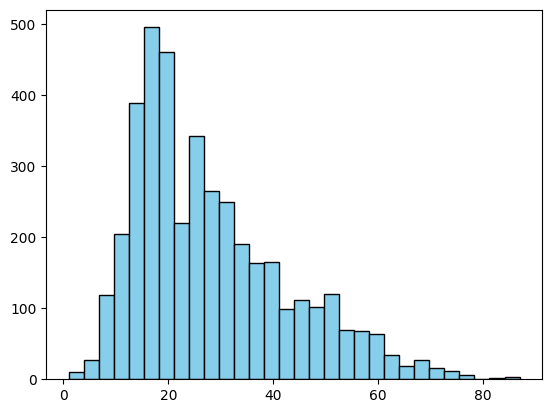

0.8747128197273702
0.7395643007730147


In [48]:
import pandas as pd
df = pd.read_excel('GSAF5.xls')
df.info()
df.head(5)
#Noticed here that the last 8 columns have no data
df.drop(columns=df.columns[-8:], inplace=True)
#Here I delete those columns
print(df['Year'].isna().sum())
df = df.dropna(subset=['Year'])
#Finding and deleting NA values
print(df['Year'].describe())
#Why is the minimum year 0? That can't be right.
df_filtered = df[df['Year'] >= 1940]
print(df_filtered['Year'].describe())
#Getting rid of values before 1940
import matplotlib.pyplot as plt
#importing so I can generate a plot
attacks_per_year = df_filtered.groupby('Year').size()
print(attacks_per_year)
#I can see now that they are increasing
df['Age'] = df['Age'].astype(str).str.extract(r'(\d+)').astype(float)
df_age = df.dropna(subset=['Age'])
df_age['Age'] = df_age['Age'].astype(int)
#Cleaning data since some are just symbols are words
plt.hist(df_age['Age'], bins=30, color='skyblue', edgecolor='black')
plt.show()
#Plotted
df['Sex_clean'] = df['Sex'].astype(str).str.strip().str.upper()
df['Sex_clean'] = df['Sex_clean'].where(df['Sex_clean'].isin(['M', 'F']))
print((df['Sex_clean'] == 'M').sum() / df['Sex_clean'].notna().sum())
#Printing percentage of male attacks
df['Type'] = df['Type'].str.strip().str.title()
df['Type'] = df['Type'].where(df['Type'].isin(['Provoked', 'Unprovoked']), 'Unknown')
#Organizing into three categories
prop_unprovoked = (df['Type'] == 'Unprovoked').mean()
print(prop_unprovoked)













## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]